# Notebook 22 - Fix the angle estimator with MATLAB-style `dohough`

This notebook is the bridge between the debugging notebooks and the production change.

We already learned:

- Current Python alpha is produced from one selected line segment.
- That creates sign flips and a flattened alpha curve.
- `abs(alpha)` helps but does not solve the estimator mismatch.
- MATLAB-style `dohough + weighted_median` on the current Python mask is much closer to MATLAB.

Goal of this notebook:

1. Show the exact replacement concept for the fascicle angle estimator.
2. Keep old notebooks as history.
3. Identify the precise source files/notebooks that should be updated next.

This notebook does not modify source files.

## The direct answer

To fix the angle estimator, the change should eventually happen in **`ultrasound_tracker`**, not by editing old notebooks one by one.

Recommended source-level change:

- Keep `ultrasound_tracker/timtrack_hough.py` as the MATLAB-compatible Hough/weighted-median implementation.
- Add a small high-level wrapper around it, for example `estimate_fascicle_alpha_dohough(mask, emask_radius, params)`.
- Update the current TimTrack sequence workflow, especially notebook 12, to call that wrapper instead of using the angle of the selected OpenCV/Frangi line segment.

Old notebooks should stay as your thinking trace. The notebook to update after the source wrapper is notebook 12, then rerun notebook 16 and the parity notebooks.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

%load_ext autoreload
%autoreload 2

current = Path.cwd()
if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


In [2]:
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ultrasound_tracker.legacy.frangi_detector import FrangiDetector
from ultrasound_tracker.matlab_compat import (
    compute_metrics,
    extract_geofeature_arrays,
    load_matlab_result,
)
from ultrasound_tracker.timtrack_hough import DoHoughParams, dohough

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

def metric_table(named_pairs):
    rows = []
    for name, ref, est in named_pairs:
        row = {"comparison": name}
        row.update(compute_metrics(ref, est))
        rows.append(row)
    return pd.DataFrame(rows)

## Load references

This cell loads:

- MATLAB `geofeatures.alpha`, our target.
- Current Python TimTrack alpha from notebook 12.
- Notebook 20's cached `dohough` alpha on the current Python mask, if available.

In [3]:
MATLAB_RESULT = PROJECT_ROOT / "data" / "matlab" / "slow_low_01_DOWN_tracked_Q=001.mat"
PY_TIMTRACK = PROJECT_ROOT / "results" / "timtrack_sequence_features_arrays.npz"
VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
ROI_PATH = PROJECT_ROOT / "data" / "rois" / "UltraTimTrack_test_rois.json"
OUT_DIR = PROJECT_ROOT / "results" / "matlab_comparison"

mat = load_matlab_result(MATLAB_RESULT)
matlab_geo = extract_geofeature_arrays(mat)
py_tim = dict(np.load(PY_TIMTRACK, allow_pickle=True))

with ROI_PATH.open() as handle:
    rois = json.load(handle)

n = min(len(matlab_geo["alpha_deg"]), len(py_tim["fascicle_angle_deg"]))
matlab_alpha = matlab_geo["alpha_deg"][:n]
current_python_alpha = np.asarray(py_tim["fascicle_angle_deg"], dtype=float)[:n]

nb20_cache = OUT_DIR / "notebook20_ported_dohough_current_mask_arrays.npz"
if nb20_cache.exists():
    nb20 = np.load(nb20_cache)
    cached_dohough_alpha = nb20["ported_alpha"][:n]
else:
    cached_dohough_alpha = np.full(n, np.nan)

print("Aligned frames:", n)
print("Notebook 20 cache exists:", nb20_cache.exists())
print("ROIs:", rois)

Aligned frames: 2666
Notebook 20 cache exists: True
ROIs: {'superficial': [15, 21, 690, 42], 'deep': [16, 298, 689, 76], 'fascicle': [17, 65, 686, 226]}


## Replacement concept

Current Python sequence logic does this:

```text
Frangi mask -> OpenCV line segments -> pick one best segment -> angle(segment)
```

The MATLAB-style replacement is:

```text
Frangi mask -> standard Hough accumulator -> top Hough peaks -> weighted median of peak angles
```

The important change is that the angle should come from the **mask-level Hough distribution**, not from one chosen segment's endpoint order.

In [4]:
# This is notebook-local prototype code.
# It shows what should later become a small reusable function in ultrasound_tracker.

def read_gray_frame(video_path, frame_idx):
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f"Could not read frame {frame_idx}")
    if frame.ndim == 3:
        return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return frame.copy()

def current_python_fascicle_mask(frame_gray, fascicle_roi, detector):
    x, y, w, h = fascicle_roi
    crop = frame_gray[y : y + h, x : x + w]
    vesselness = detector.get_vesselness_map(crop)
    binary = vesselness >= detector.threshold
    return crop, vesselness, binary

def estimate_alpha_with_dohough(binary_mask, angle_range=(8.0, 80.0), npeaks=10):
    height, width = binary_mask.shape
    params = DoHoughParams(
        angle_range=angle_range,
        thetares=1.0,
        rhores=1.0,
        emask_radius=(height / 2.0, width / 2.0),
        npeaks=npeaks,
        replace_diagonal_bias=True,
    )
    result = dohough(binary_mask, params)
    return result

fas_detector = FrangiDetector(
    sigmas=(1, 2, 4),
    alpha=0.5,
    beta=15.0,
    black_ridges=False,
    threshold=0.08,
    angle_min=10,
    angle_max=70,
    hough_threshold=15,
    min_line_length=25,
    max_line_gap=15,
)

## Single-frame demonstration

Run this cell to inspect one frame. The estimated alpha should come from `result["alpha"]`, not from an individual line segment.

Frame: 0
MATLAB alpha: 18.5
Current Python alpha: 18.434947967529297
dohough alpha: 24.0
peak alphas: [19. 27. 25. 17. 28. 24. 19. 30. 23. 21.]
peak weights: [264. 240. 239. 237. 220. 213. 205. 185. 185. 182.]


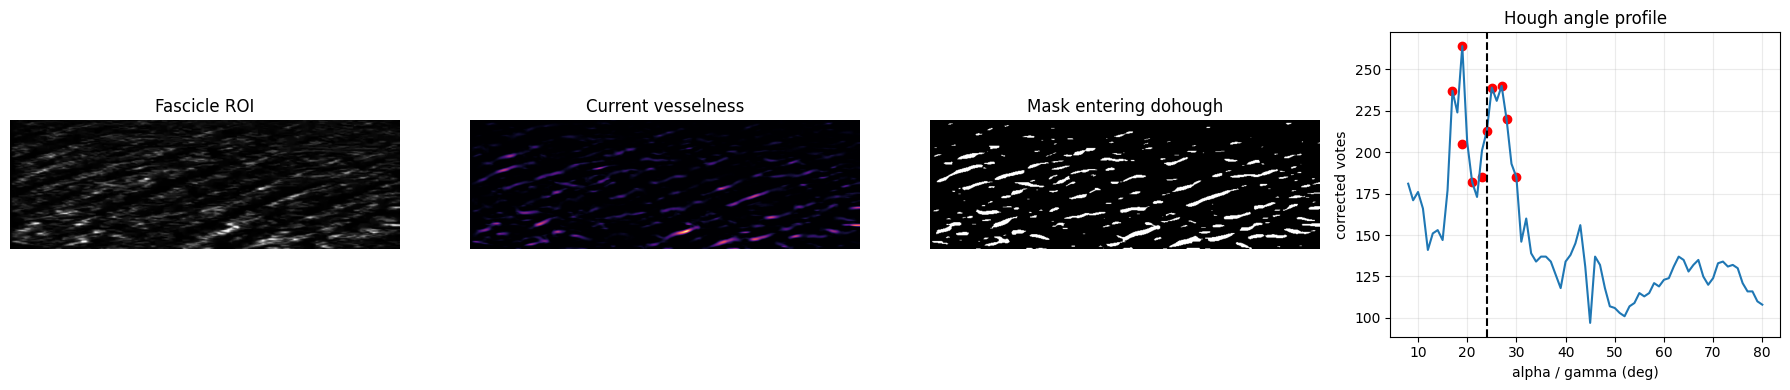

In [5]:
FRAME_IDX = 0

frame_gray = read_gray_frame(VIDEO_PATH, FRAME_IDX)
crop, vesselness, binary = current_python_fascicle_mask(
    frame_gray,
    rois["fascicle"],
    fas_detector,
)
result = estimate_alpha_with_dohough(binary)

print("Frame:", FRAME_IDX)
print("MATLAB alpha:", matlab_alpha[FRAME_IDX])
print("Current Python alpha:", current_python_alpha[FRAME_IDX])
print("dohough alpha:", result["alpha"])
print("peak alphas:", result["alphas"])
print("peak weights:", result["weights"])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(crop, cmap="gray")
axes[0].set_title("Fascicle ROI")
axes[0].axis("off")

axes[1].imshow(vesselness, cmap="magma")
axes[1].set_title("Current vesselness")
axes[1].axis("off")

axes[2].imshow(binary, cmap="gray")
axes[2].set_title("Mask entering dohough")
axes[2].axis("off")

axes[3].plot(result["gamma"], result["h_by_angle"])
axes[3].scatter(result["alphas"], result["weights"], color="red")
axes[3].axvline(result["alpha"], color="black", linestyle="--")
axes[3].set_xlabel("alpha / gamma (deg)")
axes[3].set_ylabel("corrected votes")
axes[3].set_title("Hough angle profile")

plt.tight_layout()
plt.show()

## Full-sequence result from notebook 20

If notebook 20 has already been run, this cell uses its cached full-sequence alpha. This is the evidence that the estimator replacement is worth making.

,comparison,n,bias,mae,rmse,corr
0,current selected-line alpha,2666,-11.390793,11.659603,18.967960,-0.096262
1,abs(current selected-line alpha),2666,-5.965139,6.327067,8.082938,0.137499
2,current mask + dohough alpha,2666,2.319392,2.526819,3.537244,0.866061


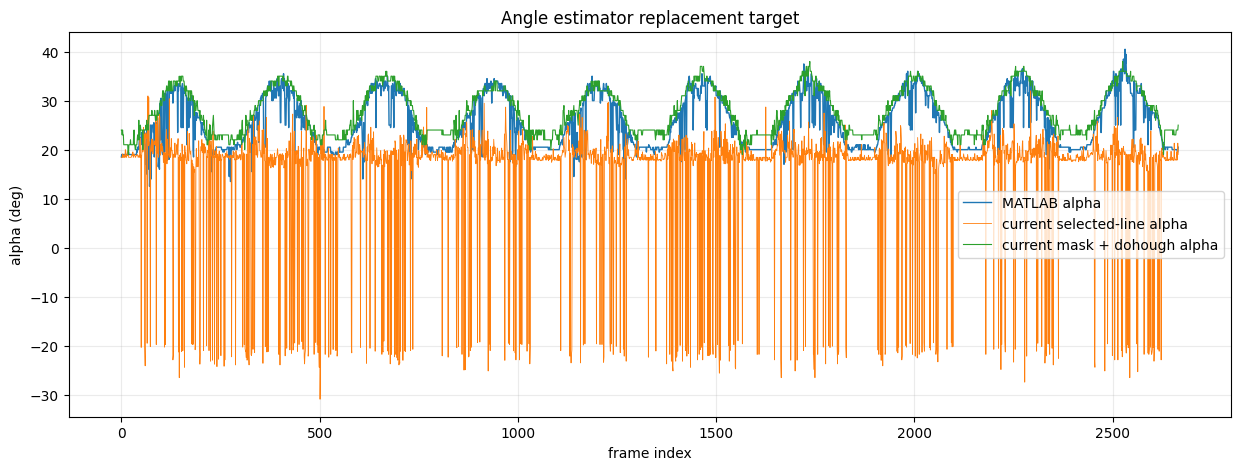

In [6]:
metrics = metric_table([
    ("current selected-line alpha", matlab_alpha, current_python_alpha),
    ("abs(current selected-line alpha)", matlab_alpha, np.abs(current_python_alpha)),
    ("current mask + dohough alpha", matlab_alpha, cached_dohough_alpha),
])
display(metrics)

plt.figure(figsize=(15, 5))
plt.plot(matlab_alpha, label="MATLAB alpha", linewidth=1)
plt.plot(current_python_alpha, label="current selected-line alpha", linewidth=0.6)
plt.plot(cached_dohough_alpha, label="current mask + dohough alpha", linewidth=0.8)
plt.ylabel("alpha (deg)")
plt.xlabel("frame index")
plt.title("Angle estimator replacement target")
plt.legend()
plt.show()

## What should change next?

The production fix should be small and staged:

1. **Add a reusable wrapper in `ultrasound_tracker`.**

   We already have the lower-level pieces in `ultrasound_tracker/timtrack_hough.py`.
   The wrapper should accept a binary fascicle mask and return:

   - `alpha_deg`
   - Hough peak angles
   - Hough peak weights
   - optional debug arrays: `h_by_angle`, `theta`, `rho`

2. **Update notebook 12, not old exploratory notebooks.**

   In notebook 12, keep the current Frangi mask for now, but replace the angle:

   ```text
   old: alpha = angle(best selected line)
   new: alpha = dohough(binary fascicle mask).alpha
   ```

   The selected line can still be kept for visualization, but it should not define alpha.

3. **Rerun notebook 12.**

   This regenerates:

   - `results/timtrack_sequence_features_arrays.npz`
   - `results/timtrack_sequence_features.csv`

4. **Rerun notebook 16.**

   This regenerates final Kalman/UltraTimTrack-like outputs using the improved alpha.

5. **Rerun parity notebooks.**

   Recheck MATLAB `alpha`, `phi`, `faslen`, then final `Fdat.Region.FL/PEN/ANG`.

6. **Only after that, return to the mask pipeline.**

   Notebook 21 showed the first MATLAB-ish mask port is not yet ready. So the mask pipeline is the next big block, but not the first production fix.

## What I need from you

Nothing else for the angle-estimator fix.

You already confirmed the important things:

- same video
- default MATLAB parameters
- approximate same ROI

The only decision I would ask before changing production code is:

**Do you want notebook 12 updated directly, or do you want a new notebook 23 that is notebook 12 plus the new MATLAB-style alpha estimator?**

My recommendation: create notebook 23 first. Once it works, then we can backport the clean version into `ultrasound_tracker`.